### Automatizacion de la busqueda en el catalogo CKAN de la CNMC y construir un mapa de años → resource_id del dataset “Precios diarios provinciales”.

    1. Consulta el catálogo CKAN con package_search usando una búsqueda por frase exacta:
Precios diarios provinciales - {año} -

    2. Selecciona el resource_id adecuado dentro del dataset encontrado:
Prioriza recursos con datastore_active = True (compatibles con datastore_search).

    3. Construye un mapa por años y maneja fallos sin detener el proceso:
        Guarda los años correctos en ids_por_anio
        Registra errores por año en errores_por_anio

## Importar librerías necesarias

In [1]:
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import time
import glob
import os

from typing import Dict, Tuple, Any, Optional
from typing import Dict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

## Variables globales y constantes

In [2]:
CKAN_URL = "https://catalogodatos.cnmc.es"

HEADERS = {"User-Agent": "IA-Proyecto-OPEC"}
HEADERS = {"User-Agent": "Application"}

MIN_YEAR = 2016
MAX_YEAR = 2025

# Carpeta donde guardaremos los CSV
os.makedirs("../data", exist_ok=True)

## CKAN helpers

In [3]:
def _package_search(query: str, rows: int = 20) -> Dict[str, Any]:
    """Llama a CKAN package_search y devuelve el JSON (parseado)."""
    url = f"{CKAN_URL}/api/3/action/package_search"
    params = {"q": f'"{query}"', "rows": rows}  # comillas => frase exacta
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

def _datastore_search_smoke_test(resource_id: str) -> bool:
    """
    Prueba rápida: verifica que el resource_id funciona con datastore_search (limit=1).
    Devuelve True si responde success=True, False si falla (HTTP/CKAN/estructura).
    """
    url = f"{CKAN_URL}/api/3/action/datastore_search"
    params = {"resource_id": resource_id, "limit": 1, "offset": 0}
    try:
        r = requests.get(url, headers=HEADERS, params=params, timeout=30)
        r.raise_for_status()
        j = r.json()
        return bool(j.get("success", False))
    except Exception:
        return False

## Selección robusta del resource_id

In [4]:
def _pick_resource_id_robusto(results: list, expected_title: Optional[str] = None) -> Tuple[str, bool]:
    """
    Elige un resource_id de forma robusta.

    Estrategia:
    1) Intentar seleccionar dataset por title (exacto y luego "contiene", case-insensitive)
    2) Si no, usar results[0] (fallback)
    3) Preferir resource con datastore_active=True
    4) Si no hay datastore_active, caer a resources[0].id (fallback web) y marcarlo como fallback=True

    Returns:
    (resource_id, used_fallback)
    """
    if not results:
        raise ValueError("No hubo resultados en package_search (results vacío).")

    dataset = None

    if expected_title:
        # 1) Match exacto por title
        for ds in results:
            if ds.get("title") == expected_title:
                dataset = ds
                break

        # 2) Match por contiene (tolerante)
        if dataset is None:
            expected_lower = expected_title.lower()
            for ds in results:
                title = (ds.get("title") or "").lower()
                if expected_lower in title:
                    dataset = ds
                    break

    # 3) Fallback dataset: el primero
    if dataset is None:
        dataset = results[0]

    resources = dataset.get("resources") or []
    if not resources:
        raise ValueError("Dataset encontrado, pero no tiene resources.")

    # Preferir un resource que esté en DataStore
    for res in resources:
        if res.get("datastore_active") is True and res.get("id"):
            return res["id"], False

    # Fallback al primer recurso, como indica la web
    first_id = resources[0].get("id")
    if first_id:
        return first_id, True

    raise ValueError("No se pudo determinar un resource_id válido (resources[0] sin id).")

## Construcción del mapa año → resource_id


In [5]:
def build_resource_map(start_year: int, end_year: int) -> Tuple[Dict[int, str], Dict[int, str]]:
    """
    Construye un diccionario {año: resource_id} para:
    'Precios diarios provinciales - {year} -'
    entre start_year y end_year (incluidos), validando rango [2016, 2025].

    Robustez:
    - Selecciona dataset por title si se puede (expected_title)
    - Prefiere datastore_active=True
    - Si cae a fallback resources[0].id, valida con datastore_search(limit=1):
        - si falla, registra error y salta ese año
    - Si un año falla, lo registra en errores y continúa.

    Devuelve: (ids_por_anio, errores_por_anio)
    """
    # Validaciones del rango
    if not (MIN_YEAR <= start_year <= MAX_YEAR):
        raise ValueError(f"start_year debe estar entre {MIN_YEAR} y {MAX_YEAR}. Recibido: {start_year}")
    if not (MIN_YEAR <= end_year <= MAX_YEAR):
        raise ValueError(f"end_year debe estar entre {MIN_YEAR} y {MAX_YEAR}. Recibido: {end_year}")
    if start_year > end_year:
        raise ValueError(f"start_year ({start_year}) no puede ser mayor que end_year ({end_year}).")

    ids_por_anio: Dict[int, str] = {}
    errores_por_anio: Dict[int, str] = {}

    for year in range(start_year, end_year + 1):
        expected = f"Precios diarios provinciales - {year} -"

        try:
            datos_catalogo = _package_search(query=expected, rows=20)

            if not datos_catalogo.get("success", False):
                errores_por_anio[year] = "CKAN devolvió success=False."
                print(f"[{year}] ERROR: CKAN devolvió success=False")
                continue

            result = datos_catalogo.get("result", {}) or {}
            results = result.get("results", []) or []
            count = result.get("count", 0)

            if count == 0 or not results:
                errores_por_anio[year] = f"No se encontraron datasets con query: {expected}"
                print(f"[{year}] ERROR: No se encontraron resultados (count=0).")
                continue

            resource_id, used_fallback = _pick_resource_id_robusto(results, expected_title=expected)

            # Si usamos fallback (resources[0].id), validamos que sea realmente DataStore (datastore_search funcione)
            if used_fallback:
                ok = _datastore_search_smoke_test(resource_id)
                if not ok:
                    errores_por_anio[year] = (
                        "Se eligió resources[0].id como fallback, pero datastore_search(limit=1) falló. "
                        f"resource_id={resource_id}"
                    )
                    print(f"[{year}] ERROR: fallback resource_id NO funciona con datastore_search -> {resource_id}")
                    continue
                print(f"[{year}] OK (fallback validado) -> resource_id: {resource_id}")
            else:
                print(f"[{year}] OK -> resource_id: {resource_id}")

            ids_por_anio[year] = resource_id

        except requests.exceptions.RequestException as e:
            errores_por_anio[year] = f"Error HTTP/red: {repr(e)}"
            print(f"[{year}] ERROR HTTP/red: {e}")
            continue
        except Exception as e:
            errores_por_anio[year] = f"Error: {repr(e)}"
            print(f"[{year}] ERROR: {e}")
            continue

    print("\n=== Resumen ===")
    print(f"Años OK: {len(ids_por_anio)} -> {sorted(ids_por_anio.keys())}")
    print(f"Años con error: {len(errores_por_anio)} -> {sorted(errores_por_anio.keys())}")

    return ids_por_anio, errores_por_anio

In [6]:
ids_por_anio, errores_por_anio = build_resource_map(2016, 2025)
ids_por_anio
errores_por_anio

[2016] OK -> resource_id: a385ec5d-a22b-4029-a322-ce3f40241597
[2017] OK -> resource_id: 4c94e9aa-4973-471c-ae19-6658ec57e865
[2018] OK -> resource_id: e2a074ed-789e-43fc-b7bf-e2ba6106458a
[2019] OK -> resource_id: 898c5d4b-c78b-4653-9226-bc24de59846a
[2020] OK -> resource_id: beb221c5-2be6-472a-bb25-bd6d2343e014
[2021] OK -> resource_id: 9bb7d9fe-b99a-42ea-96f7-35c735b56612
[2022] OK -> resource_id: 42fca586-6582-40c8-8df5-6ebbb8fbfd73
[2023] OK -> resource_id: b5a89db0-239f-4c8a-bd98-6575858359ae
[2024] OK -> resource_id: 141fdb3b-7c56-4eed-bf8d-bee56e577aa6
[2025] OK -> resource_id: 3b60baeb-a422-4b6d-a35f-af748adefcb1

=== Resumen ===
Años OK: 10 -> [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Años con error: 0 -> []


{}

# Resolución automática de `resource_id` (CNMC – CKAN)

## Objetivo
Esta celda implementa un proceso **automático y robusto** para obtener los identificadores
`resource_id` de los datasets **“Precios diarios provinciales”** publicados por la CNMC,
para un rango de años definido por el usuario (**2016–2025**).

El resultado será un **mapa año → resource_id**, que se utilizará posteriormente para
descargar los datos reales de precios desde la API.

---

## Contexto: cómo funciona la API de la CNMC
La plataforma de datos de la CNMC está basada en **CKAN**, que separa el acceso a los datos en dos niveles:

1. **Catálogo (`package_search`)**  
   Permite buscar datasets y obtener metadatos (títulos, recursos, identificadores).
2. **Almacén de datos (`datastore_search`)**  
   Permite acceder a los registros reales, pero requiere conocer previamente el `resource_id`.

Esta celda cubre **exclusivamente el primer nivel**: la resolución automática de los `resource_id`.

---

## Funcionamiento del código
Para cada año del rango indicado:

- Se construye dinámicamente la consulta:
    Precios diarios provinciales - {año} -

- Se consulta el catálogo mediante `package_search`.
- Se selecciona el dataset adecuado:
- Coincidencia exacta por título.
- Coincidencia parcial (el título contiene el texto esperado).
- Fallback al primer resultado si no hay coincidencia clara.
- Se selecciona el `resource_id`:
- Prioridad a recursos con `datastore_active = True`.
- Fallback a `resources[0].id`, validando que funcione con `datastore_search(limit=1)`.
- Si ocurre un error en un año concreto, se registra y el proceso continúa con el siguiente año.

---

## Salida de la función
La función `build_resource_map(start_year, end_year)` devuelve:

- **`ids_por_anio`**  
Diccionario con la forma:
    { año: resource_id }

Contiene únicamente los años resueltos correctamente.

- **`errores_por_anio`**  
Diccionario con los años que fallaron y el motivo del error.

Esto permite separar claramente los años válidos de los que requieren revisión.

---

## Ventajas del enfoque
- Proceso completamente automatizado (sin intervención manual).
- Robusto ante cambios en el orden de los datasets o recursos.
- Compatible con la documentación oficial de CKAN.
- Preparado para reutilizarse en fases posteriores del proyecto (descarga y análisis de datos).

---

> **Nota:**  
> Esta celda **no descarga los datos**. Su única responsabilidad es identificar correctamente
> los `resource_id` necesarios para acceder al DataStore.


## Descarga, limpieza y guardado de los datos


In [7]:
def descargar_recurso_completo(resource_id: str, limit: int = 5000) -> list:
    """
    Descarga TODOS los registros de un resource CKAN usando paginación (limit/offset).
    """
    registros = []
    offset = 0

    while True:
        url = f"{CKAN_URL}/api/3/action/datastore_search"
        params = {"resource_id": resource_id, "limit": limit, "offset": offset}

        r = requests.get(url, headers=HEADERS, params=params, timeout=60)
        r.raise_for_status()

        data = r.json()["result"]["records"]
        if not data:
            break

        registros.extend(data)
        offset += limit
        print(f"⬇ Descargados {len(registros)} registros hasta ahora...")
        time.sleep(0.2)

    return registros

In [8]:
def descargar_limpiar_y_guardar(resource_id: str, year: int) -> None:
    """
    Descarga el dataset (por resource_id), lo convierte a DataFrame, lo limpia y lo guarda
    como ../data/precios_petroleo_{year}_limpio.csv
    """
    # Descargar todos los datos del recurso
    datos = descargar_recurso_completo(resource_id)

    # Convertir a DataFrame
    df = pd.DataFrame(datos)

    # Limpiar espacios de los nombres de columnas
    df.columns = df.columns.str.strip()

    # Renombrar columnas (como lo tenías)
    df.rename(columns={
        "fecha_precio": "fecha",
        "provincia": "provincia",
        "producto": "producto",
        "promedio_de_pai_diario_cubo": "pai",
        "promedio_de_pvp_diario_cubo": "pvp"
    }, inplace=True)

    # Convertir tipos correctamente
    df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d", errors="coerce")
    df["pai"] = pd.to_numeric(df["pai"], errors="coerce")
    df["pvp"] = pd.to_numeric(df["pvp"], errors="coerce")

    # Eliminar filas con nulos
    df.dropna(inplace=True)

    # Guardar CSV final limpio
    out_path = f"../data/precios_petroleo_{year}_limpio.csv"
    df.to_csv(out_path, index=False)

    print(f"Datos guardados en '{out_path}' ({len(df)} registros)")

In [9]:
def descargar_por_anios(ids_por_anio: Dict[int, str]) -> None:
    """
    Recibe un diccionario {year: resource_id} y descarga/guarda cada año en orden.
    """
    for year in sorted(ids_por_anio.keys()):
        resource_id = ids_por_anio[year]
        print(f"\n===== Procesando año {year} =====")
        descargar_limpiar_y_guardar(resource_id, year)

    print("\nProceso terminado: todos los años fueron procesados.")

In [10]:
# === USO ===
# cuando ya se tienen los IDs ids_por_anio del paso anterior (build_resource_map)
descargar_por_anios(ids_por_anio)

# Si  se quiere probar con un año puntual deberiamos buscarlo en el build_resource_map que se ejecuto antes
# Por ejemplo, para 2020:
#descargar_limpiar_y_guardar(ids_por_anio[2020], 2020)


===== Procesando año 2016 =====
⬇ Descargados 5000 registros hasta ahora...
⬇ Descargados 10000 registros hasta ahora...
⬇ Descargados 15000 registros hasta ahora...
⬇ Descargados 20000 registros hasta ahora...
⬇ Descargados 25000 registros hasta ahora...
⬇ Descargados 30000 registros hasta ahora...
⬇ Descargados 35000 registros hasta ahora...
⬇ Descargados 40000 registros hasta ahora...
⬇ Descargados 45000 registros hasta ahora...
⬇ Descargados 50000 registros hasta ahora...
⬇ Descargados 55000 registros hasta ahora...
⬇ Descargados 60000 registros hasta ahora...
⬇ Descargados 65000 registros hasta ahora...
⬇ Descargados 70000 registros hasta ahora...
⬇ Descargados 75000 registros hasta ahora...
⬇ Descargados 75762 registros hasta ahora...
Datos guardados en '../data/precios_petroleo_2016_limpio.csv' (75762 registros)

===== Procesando año 2017 =====
⬇ Descargados 5000 registros hasta ahora...
⬇ Descargados 10000 registros hasta ahora...
⬇ Descargados 15000 registros hasta ahora...
⬇

# Parte IA – Análisis y predicción de precios


## Carga del dataset consolidado (2016–2025)
Al final hemos decidido cargar los datos con glob ya que se hace en menos líeneas.

In [11]:

files = glob.glob("../data/precios_petroleo_*_limpio.csv")
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

df.head()

,_id,fecha,provincia,producto,pai,pvp
0,1,2016-01-01,Albacete,Gasolina 95 E5,0.482,1.155
1,2,2016-01-01,Albacete,Gasolina 98 E5,0.552,1.278
2,3,2016-01-01,Albacete,Gasóleo A habitual,0.441,0.993
3,4,2016-01-01,Albacete,Gasóleo Premium,0.504,1.069
4,5,2016-01-01,Alicante/Alacant,Gasolina 95 E5,0.483,1.157


## Observación inicial de los datos


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756138 entries, 0 to 756137
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   _id        756138 non-null  int64  
 1   fecha      756138 non-null  object 
 2   provincia  756138 non-null  object 
 3   producto   756138 non-null  object 
 4   pai        756138 non-null  float64
 5   pvp        756138 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 34.6+ MB


In [13]:
df.describe()

,_id,pai,pvp
count,756138.000000,756138.000000,756138.000000
mean,37807.462778,0.758646,1.400902
std,21827.947137,0.202601,0.264096
min,1.000000,0.363000,0.639000
25%,18904.000000,0.601000,1.207000
50%,37807.000000,0.718000,1.357000
75%,56711.000000,0.889000,1.574000
max,75762.000000,1.656000,2.367000


## Limpieza y preprocesamiento de los datos


In [14]:
# Eliminar columna identificador
df = df.drop(columns=["_id"])

# Conversión de fecha
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Eliminación de posibles nulos
df = df.dropna()

## Ingeniería de variables temporales


In [15]:
df["year"] = df["fecha"].dt.year
df["month"] = df["fecha"].dt.month
df["day"] = df["fecha"].dt.day

## Selección de variables predictoras y objetivo

In [ ]:
# "pai" lo elimino para pruebas pero podría volver a incluirlo
X = df[["provincia", "producto", "year", "month", "day"]]
y = df["pvp"]

X = pd.get_dummies(X, drop_first=True)

## División en conjuntos de entrenamiento y test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Entrenamiento del modelo de Machine Learning

In [26]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)



MemoryError: Unable to allocate 132. MiB for an array with shape (57, 604910) and data type float32

## Evaluación del modelo

In [19]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.4f}")
mae, rmse

MAE: 0.0005


(0.0004901534438069584, 0.0017181874971085548)

## Métricas adicionales de evaluación del modelo

In [20]:
r2 = r2_score(y_test, y_pred)
score = model.score(X_test, y_test)

r2, score

(0.9999577033287576, 0.9999577033287576)

## Comparación de rendimiento: entrenamiento vs test

In [21]:
y_pred_train = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

mae_train, rmse_train

(0.0001828032351923967, 0.0006585640466846434)

## Importancia de las variables

In [22]:

importancias = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(10)

year                                0.655492
pai                                 0.112827
producto_Gasolina 98 E5             0.087226
provincia_Melilla                   0.031096
provincia_Santa Cruz de Tenerife    0.027200
provincia_Ceuta                     0.026968
provincia_Palmas, Las               0.026461
producto_Gasóleo A habitual         0.015391
month                               0.007112
producto_Gasóleo Premium            0.007027
dtype: float64

## Visualización real vs predicción

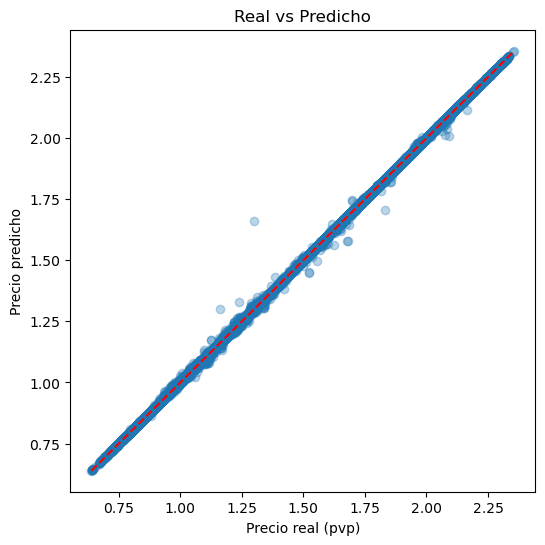

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Precio real (pvp)")
plt.ylabel("Precio predicho")
plt.title("Real vs Predicho")
plt.show()

## Visualiazación mapa de calor

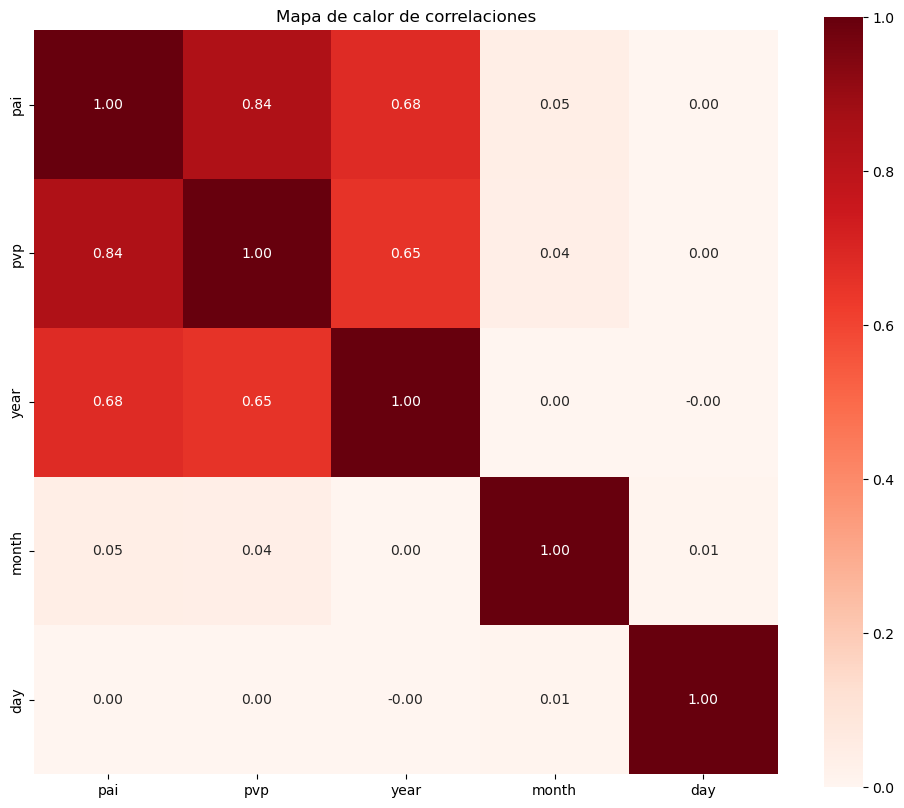

In [24]:
plt.figure(figsize=(12, 10))

df_num = df.select_dtypes(include='number')
cor = df_num.corr()

sns.heatmap(
    cor,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    square=True
)

plt.title("Mapa de calor de correlaciones")
plt.show()


## Persistencia del modelo entrenado

In [29]:
joblib.dump(
    {
        "model": model,
        "columns": X.columns
    },
    "../data/modelo_precios_carburantes.pkl"
)

# joblib.dump(
#     {
#         "model": model,
#         "columns": X.columns
#     },
#     "modelo_precios_carburantes.joblib",
#     compress=7
# )


['../data/modelo_precios_carburantes.pkl']

## Aplicación web (Streamlit)

Se desarrollará una aplicación web que permitirá al usuario:

- Seleccionar provincia
- Seleccionar tipo de carburante
- Introducir una fecha
- Obtener el precio estimado del carburante

La aplicación utilizará el modelo entrenado y persistido en este cuaderno.
